# Exoplanet Demographics — NASA Exoplanet Archive
### Astrofísica Computacional · OAN · 2026-I · Proyecto 3 (Opción D)

**Autor:** _Andrés Felipe Suárez Reyes_
**Dataset:** NASA Exoplanet Archive, tabla `pscomppars` (Planetary Systems Composite Parameters), planetas confirmados.

Este notebook implementa el pipeline de 5 etapas pedido en el enunciado:
1. Adquisición de datos (Astroquery → CSV crudo)
2. Diseño e ingesta de una base de datos SQLite normalizada
3. Consultas SQL y carga a pandas
4. Dashboard estadístico multi-panel
5. Interpretación científica

## Etapa 1 — Adquisición de datos

**¿Por qué esta tabla?** `pscomppars` es la tabla "compuesta" del archivo: para cada planeta confirmado,
la NASA ya resolvió cuál es el mejor valor publicado entre las distintas referencias (en vez de tener
que combinar nosotros mismos filas duplicadas por publicación). Es la tabla recomendada para análisis
estadísticos de la población completa de exoplanetas.

**Parámetros seleccionados** (con unidades):
| Columna | Significado | Unidad |
|---|---|---|
| `pl_name` | Nombre del planeta | — |
| `hostname` | Nombre de la estrella anfitriona | — |
| `pl_orbper` | Periodo orbital | días |
| `pl_orbsmax` | Semieje mayor | AU |
| `pl_rade` | Radio del planeta | radios terrestres (R⊕) |
| `pl_bmasse` | Masa del planeta (best-mass) | masas terrestres (M⊕) |
| `pl_eqt` | Temperatura de equilibrio | K |
| `st_teff` | Temperatura efectiva de la estrella anfitriona | K |
| `discoverymethod` | Método de detección | — |
| `disc_year` | Año de descubrimiento | — |

**Filtro de calidad:** excluimos planetas marcados como controvertidos (`pl_controv_flag = 0`) y exigimos
que radio, masa y temperatura de equilibrio no sean nulos, porque son las tres cantidades físicas centrales
que vamos a graficar y correlacionar.


In [ ]:
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive as NEA #API que permite consultar la base de datos de exoplanetas de la NASA
import pandas as pd
import numpy as np

COLUMNS = ['pl_name', 'hostname', 'pl_orbper', 'pl_orbsmax', 'pl_rade',
           'pl_bmasse', 'pl_eqt', 'st_teff', 'discoverymethod', 'disc_year']

WHERE_CLAUSE = (  #condiciones de filtrado para la consulta a la base de datos
    "pl_controv_flag = 0 "
    "AND pl_rade IS NOT NULL "
    "AND pl_bmasse IS NOT NULL "
    "AND pl_eqt IS NOT NULL"
)
#creación de un DataFrame a partir de la consulta a la base de datos de exoplanetas de la NASA
table = NEA.query_criteria(
    table='pscomppars',
    select=', '.join(COLUMNS),
    where=WHERE_CLAUSE,
)
#conversión del resultado de la consulta a un DataFrame de pandas
raw_df = table.to_pandas()
#ver si el DataFrame está vacío y lanzar un error si es así
if len(raw_df) == 0:
    raise RuntimeError('No se recibieron objetos -- revisa los parámetros de la consulta')
#verificar que todas las columnas esperadas están presentes en el DataFrame
missing_cols = set(COLUMNS) - set(raw_df.columns)
assert not missing_cols, f'Faltan columnas esperadas: {missing_cols}'

n_before = len(raw_df) #datos antes de filtrar NAN
raw_df = raw_df.dropna(subset=['pl_rade', 'pl_bmasse', 'pl_eqt']) #FILTRO DE CALIDAD: eliminamos filas con valores nulos en las columnas críticas
n_after = len(raw_df) #datos después de filtrar NAN

raw_df.to_csv('raw_data.csv', index=False) #guardar los datos filtrados en un archivo CSV
print(f'Filas devueltas por la consulta: {n_before}')
print(f'Filas tras el corte de calidad (dropna en columnas críticas): {n_after}')
raw_df.head()


Filas devueltas por la consulta: 5688
Filas tras el corte de calidad (dropna en columnas críticas): 5688


,pl_name,hostname,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_eqt,st_teff,discoverymethod,disc_year
0,Kepler-1597 b,Kepler-1597,2.946542,0.04136,1.06,1.20,1497.0,6377.0,Transit,2016
1,Kepler-687 b,Kepler-687,20.505870,0.13260,3.52,12.20,518.0,4841.0,Transit,2016
2,Kepler-1596 b,Kepler-1596,66.373379,0.32370,1.90,4.27,471.0,5706.0,Transit,2016
3,Kepler-692 b,Kepler-692,21.812935,0.14950,3.11,9.85,639.0,5440.0,Transit,2016
4,Kepler-150 c,Kepler-150,7.381998,0.07300,3.69,13.20,876.0,5560.0,Transit,2014


**Preguntas de la guía (Etapa 1):**

- *¿Cuántos objetos devolvió la consulta antes/después del corte de calidad?* → ver el print de arriba
  (la consulta ya filtra `pl_controv_flag = 0` y no-nulos en el WHERE del ADQL, así que el `dropna`
  posterior normalmente no elimina filas adicionales; se deja como salvaguarda explícita).
- *¿Sesgos de selección conocidos?* El archivo está dominado por el método de tránsito (misión *Kepler*),
  lo que sesga la muestra hacia planetas de periodo corto y tamaño detectable en tránsito (efecto de
  selección geométrica + fotométrica). Los métodos de velocidad radial y microlente cubren regiones
  distintas del espacio periodo-masa.
- *¿Qué ventana temporal / cobertura cubre?* Todos los años de descubrimiento disponibles hasta la fecha
  de la consulta (ver columna `disc_year`); no hay corte de tiempo explícito, es la muestra confirmada completa.


## Etapa 2 — Diseño e ingesta de la base de datos SQLite

**Diseño relacional (normalizado):** en vez de una sola tabla plana, separamos la información en dos
entidades porque **una estrella puede tener varios planetas** (relación 1-a-muchos). Repetir `st_teff`
en cada fila de planeta violaría la normalización (redundancia + riesgo de inconsistencia si un valor
cambiara). Por eso:

- **`stars`**: una fila por estrella anfitriona única (`hostname` con restricción `UNIQUE`), con su temperatura
  efectiva y la clase espectral derivada.
- **`planets`**: una fila por planeta, con una **llave foránea** `star_id` que apunta a `stars.id`.
- **`metadata`**: tabla clave-valor para dejar trazabilidad de cuándo y cómo se generó la base de datos.

**¿Por qué derivar la clase espectral (`spec_class`) a partir de `st_teff` en vez de usar `st_spectype`
directamente?** Porque en este dataset `st_spectype` viene vacío para ~62% de las estrellas, mientras que
`st_teff` está disponible en >99% de los casos. Usamos los rangos estándar de temperatura de la secuencia
principal (Morgan-Keenan) para clasificar: O > 30000 K, B 10000–30000, A 7500–10000, F 6000–7500,
G 5200–6000, K 3700–5200, M < 3700 K. 


In [ ]:
def spectral_class_from_teff(teff): #definición de la función para clasificar estrellas según su temperatura efectiva
    """Clasifica una estrella en O/B/A/F/G/K/M según su temperatura efectiva [K],
    usando los rangos estándar de la secuencia principal (Morgan-Keenan).
    Devuelve None si teff es NaN."""
    if pd.isna(teff):
        return None
    if teff > 30000:
        return 'O'
    elif teff > 10000:
        return 'B'
    elif teff > 7500:
        return 'A'
    elif teff > 6000:
        return 'F'
    elif teff > 5200:
        return 'G'
    elif teff > 3700:
        return 'K'
    else:
        return 'M'

df = raw_df.copy()
df['spec_class'] = df['st_teff'].apply(spectral_class_from_teff) #creo una nueva columna 'spec_class' aplicando la función spectral_class_from_teff a la columna 'st_teff'

conditions = [df['pl_eqt'] < 273, df['pl_eqt'] < 373] #definición de las condiciones para clasificar los exoplanetas según su temperatura de equilibrio
choices = ['Cold', 'Temperate']
df['temp_zone'] = np.select(conditions, choices, default='Hot')

df.head()


,pl_name,hostname,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_eqt,st_teff,discoverymethod,disc_year,spec_class,temp_zone
0,Kepler-1597 b,Kepler-1597,2.946542,0.04136,1.06,1.20,1497.0,6377.0,Transit,2016,F,Hot
1,Kepler-687 b,Kepler-687,20.505870,0.13260,3.52,12.20,518.0,4841.0,Transit,2016,K,Hot
2,Kepler-1596 b,Kepler-1596,66.373379,0.32370,1.90,4.27,471.0,5706.0,Transit,2016,G,Hot
3,Kepler-692 b,Kepler-692,21.812935,0.14950,3.11,9.85,639.0,5440.0,Transit,2016,G,Hot
4,Kepler-150 c,Kepler-150,7.381998,0.07300,3.69,13.20,876.0,5560.0,Transit,2014,G,Hot


In [ ]:
import sqlite3
import datetime

DB_PATH = 'astro_project.db'
conn = sqlite3.connect(DB_PATH) #conexión a la base de datos SQLite o creación de la misma si no existe
cur = conn.cursor() #es como una consola de SQL, permite ejecutar comandos SQL en la base de datos

# Reiniciamos las tablas en cada corrida para que el notebook sea
# reproducible (ejecutarlo dos veces no debe duplicar filas).
cur.executescript('''
DROP TABLE IF EXISTS planets;
DROP TABLE IF EXISTS stars;
DROP TABLE IF EXISTS metadata;
''')
#Tabla relacional (entidad-relacion)
cur.execute('''
CREATE TABLE stars (
    id          INTEGER PRIMARY KEY AUTOINCREMENT,
    hostname    TEXT UNIQUE NOT NULL,
    st_teff     REAL,
    spec_class  TEXT
)
''')
#Tabla relacional (entidad-relacion)
cur.execute('''
CREATE TABLE planets (
    id               INTEGER PRIMARY KEY AUTOINCREMENT,
    pl_name          TEXT UNIQUE NOT NULL,
    star_id          INTEGER NOT NULL,
    pl_orbper        REAL,
    pl_orbsmax       REAL,
    pl_rade          REAL,
    pl_bmasse        REAL,
    pl_eqt           REAL,
    temp_zone        TEXT,
    discoverymethod  TEXT,
    disc_year        INTEGER,
    retrieved_at     TEXT,
    FOREIGN KEY (star_id) REFERENCES stars (id)
)
''')
#Tabla relacional (key-value)
cur.execute('''
CREATE TABLE metadata (
    key   TEXT PRIMARY KEY,
    value TEXT
)
''')

# Índices: aceleran los JOIN y los filtros que se usan en la Etapa 3.
# `star_id` se busca en cada JOIN planets-stars; `discoverymethod` se
# filtra/agrupa en varias consultas y en el dashboard.
cur.execute('CREATE INDEX idx_planets_star_id ON planets (star_id)')
cur.execute('CREATE INDEX idx_planets_discoverymethod ON planets (discoverymethod)')

conn.commit()
print('Esquema creado (con índices en star_id y discoverymethod).')


Esquema creado (con índices en star_id y discoverymethod).


**Diagrama entidad-relación** del esquema recién creado, generado directamente desde las
definiciones de columnas de arriba (no es un dibujo aparte -- si cambias el esquema en la celda
anterior, esta celda hay que actualizarla junto con él).


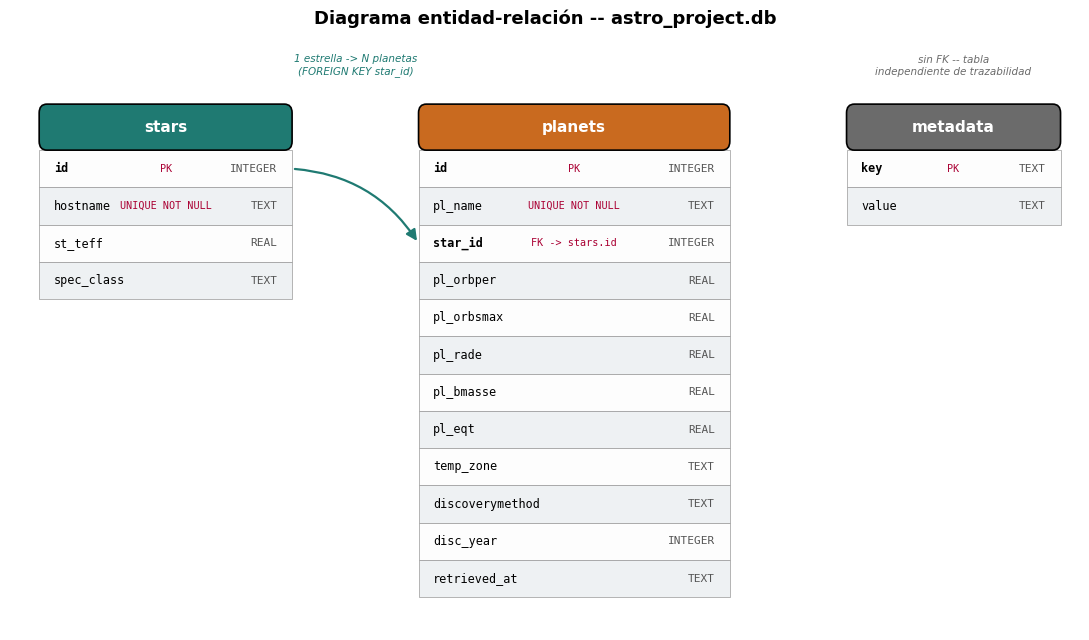

In [4]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, FancyArrowPatch

STARS_COLS = [
    ('id', 'INTEGER', 'PK'),
    ('hostname', 'TEXT', 'UNIQUE NOT NULL'),
    ('st_teff', 'REAL', ''),
    ('spec_class', 'TEXT', ''),
]
PLANETS_COLS = [
    ('id', 'INTEGER', 'PK'),
    ('pl_name', 'TEXT', 'UNIQUE NOT NULL'),
    ('star_id', 'INTEGER', 'FK -> stars.id'),
    ('pl_orbper', 'REAL', ''),
    ('pl_orbsmax', 'REAL', ''),
    ('pl_rade', 'REAL', ''),
    ('pl_bmasse', 'REAL', ''),
    ('pl_eqt', 'REAL', ''),
    ('temp_zone', 'TEXT', ''),
    ('discoverymethod', 'TEXT', ''),
    ('disc_year', 'INTEGER', ''),
    ('retrieved_at', 'TEXT', ''),
]
METADATA_COLS = [
    ('key', 'TEXT', 'PK'),
    ('value', 'TEXT', ''),
]

ROW_H = 0.34
HEADER_H = 0.42

def draw_table(ax, x, y_top, width, title, cols, header_color):
    """Dibuja una 'tarjeta' estilo ERD para una tabla SQL: encabezado con el
    nombre de la tabla y una fila por columna (nombre, tipo, PK/FK/UNIQUE).
    Devuelve la altura total dibujada, para poder ajustar los límites del eje."""
    total_h = HEADER_H + ROW_H * len(cols)
    ax.add_patch(FancyBboxPatch((x, y_top - HEADER_H), width, HEADER_H,
                                 boxstyle='round,pad=0,rounding_size=0.08',
                                 linewidth=1.2, edgecolor='black', facecolor=header_color, zorder=3))
    ax.text(x + width / 2, y_top - HEADER_H / 2, title, ha='center', va='center',
            fontsize=11, fontweight='bold', color='white', zorder=4)
    for i, (name, dtype, tag) in enumerate(cols):
        ry = y_top - HEADER_H - ROW_H * (i + 1)
        face = '#fdfdfd' if i % 2 == 0 else '#eef1f3'
        ax.add_patch(Rectangle((x, ry), width, ROW_H, linewidth=0.5,
                                edgecolor='#999999', facecolor=face, zorder=2))
        label = f'{name}  ' + (f'({tag})' if tag else '')
        weight = 'bold' if 'PK' in tag or 'FK' in tag else 'normal'
        ax.text(x + 0.15, ry + ROW_H / 2, name, ha='left', va='center',
                fontsize=8.5, family='monospace', fontweight=weight, zorder=4)
        ax.text(x + width - 0.15, ry + ROW_H / 2, dtype, ha='right', va='center',
                fontsize=8, family='monospace', color='#555555', zorder=4)
        if tag:
            ax.text(x + width / 2, ry + ROW_H / 2, tag, ha='center', va='center',
                    fontsize=7.3, family='monospace', color='#a03', zorder=4)
    return total_h

fig, ax = plt.subplots(figsize=(11, 6.5))

stars_h = draw_table(ax, 0.3, 6.0, 2.6, 'stars', STARS_COLS, '#1f7a72')
planets_h = draw_table(ax, 4.2, 6.0, 3.2, 'planets', PLANETS_COLS, '#c96a1f')
meta_h = draw_table(ax, 8.6, 6.0, 2.2, 'metadata', METADATA_COLS, '#6b6b6b')

# FK relationship: stars.id (row 0) -> planets.star_id (row 2)
y_star_id = 6.0 - HEADER_H - ROW_H * 0.5
y_planet_fk = 6.0 - HEADER_H - ROW_H * 2.5
arrow = FancyArrowPatch((2.9, y_star_id), (4.2, y_planet_fk),
                         connectionstyle='arc3,rad=-0.25', arrowstyle='-|>',
                         mutation_scale=16, linewidth=1.6, color='#1f7a72', zorder=5)
ax.add_patch(arrow)
ax.text(3.55, 6.0 + 0.25, '1 estrella -> N planetas\n(FOREIGN KEY star_id)',
        ha='center', va='bottom', fontsize=7.5, color='#1f7a72', style='italic')

ax.text(9.7, 6.0 + 0.25, 'sin FK -- tabla\nindependiente de trazabilidad',
        ha='center', va='bottom', fontsize=7.5, color='#6b6b6b', style='italic')

ax.set_xlim(0, 11)
ax.set_ylim(6.0 - max(stars_h, planets_h, meta_h) - 0.3, 6.6)
ax.axis('off')
ax.set_title('Diagrama entidad-relación -- astro_project.db', fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('figures/erd_schema.png', dpi=200, bbox_inches='tight')
plt.show()


**Ingesta:** primero insertamos las estrellas únicas (para poder obtener su `id` autogenerado),
y luego los planetas referenciando ese `id`. Usamos **consultas parametrizadas** (`?` placeholders)
en vez de f-strings/concatenación de texto — esto no es solo estilo: concatenar valores directamente
en el SQL abre la puerta a *SQL injection* y además falla con comillas o caracteres especiales en nombres.


In [5]:
retrieved_at = datetime.datetime.now(datetime.timezone.utc).isoformat()

# --- Insertar estrellas únicas ---
stars_df = df[['hostname', 'st_teff', 'spec_class']].drop_duplicates(subset='hostname')
star_id_map = {}
for row in stars_df.itertuples(index=False):
    cur.execute(
        'INSERT INTO stars (hostname, st_teff, spec_class) VALUES (?, ?, ?)',
        (row.hostname, None if pd.isna(row.st_teff) else float(row.st_teff), row.spec_class)
    )
    star_id_map[row.hostname] = cur.lastrowid

# --- Insertar planetas ---
for row in df.itertuples(index=False):
    cur.execute(
        '''INSERT INTO planets
           (pl_name, star_id, pl_orbper, pl_orbsmax, pl_rade, pl_bmasse,
            pl_eqt, temp_zone, discoverymethod, disc_year, retrieved_at)
           VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)''',
        (
            row.pl_name,
            star_id_map[row.hostname],
            None if pd.isna(row.pl_orbper) else float(row.pl_orbper),
            None if pd.isna(row.pl_orbsmax) else float(row.pl_orbsmax),
            float(row.pl_rade),
            float(row.pl_bmasse),
            float(row.pl_eqt),
            row.temp_zone,
            row.discoverymethod,
            None if pd.isna(row.disc_year) else int(row.disc_year),
            retrieved_at,
        )
    )

metadata_rows = [
    ('source', 'NASA Exoplanet Archive - pscomppars'),
    ('query_where_clause', WHERE_CLAUSE),
    ('n_planets', str(len(df))),
    ('n_stars', str(len(stars_df))),
    ('retrieved_at_utc', retrieved_at),
]
cur.executemany('INSERT OR REPLACE INTO metadata (key, value) VALUES (?, ?)', metadata_rows)

conn.commit()
print(f'{len(df)} planetas y {len(stars_df)} estrellas insertadas.')


5688 planetas y 4252 estrellas insertadas.


## Etapa 3 — Consultas SQL y carga a pandas

Aquí se ejercitan explícitamente: `SELECT`, `WHERE` parametrizado, `JOIN`, `GROUP BY`, `ORDER BY`,
`COUNT`, `AVG`, `MIN`, `MAX`.

Cerramos y reabrimos la conexión para simular exactamente el flujo del enunciado (Etapa 3 es
independiente de Etapa 2 — cualquiera podría abrir `astro_project.db` después y repetir este análisis).


In [47]:
conn.close()
conn = sqlite3.connect(DB_PATH)

# 1) SELECT simple
df_all = pd.read_sql('SELECT * FROM planets', conn)
print('Filas en planets:', len(df_all))
df_all.head()


Filas en planets: 5688


,id,pl_name,star_id,pl_orbper,pl_orbsmax,pl_rade,pl_bmasse,pl_eqt,temp_zone,discoverymethod,disc_year,retrieved_at
0,1,Kepler-1597 b,1,2.946542,0.04136,1.06,1.20,1497.0,Hot,Transit,2016,2026-07-10T21:27:35.346472+00:00
1,2,Kepler-687 b,2,20.505870,0.13260,3.52,12.20,518.0,Hot,Transit,2016,2026-07-10T21:27:35.346472+00:00
2,3,Kepler-1596 b,3,66.373379,0.32370,1.90,4.27,471.0,Hot,Transit,2016,2026-07-10T21:27:35.346472+00:00
3,4,Kepler-692 b,4,21.812935,0.14950,3.11,9.85,639.0,Hot,Transit,2016,2026-07-10T21:27:35.346472+00:00
4,5,Kepler-150 c,5,7.381998,0.07300,3.69,13.20,876.0,Hot,Transit,2014,2026-07-10T21:27:35.346472+00:00


In [7]:
# 2) WHERE parametrizado: planetas "grandes" detectados por un método distinto a Transit
threshold_radius = 4.0  # R_earth, aprox. el límite entre "super-Tierra" y "mini-Neptuno"
df_sub = pd.read_sql(
    '''SELECT pl_name, pl_rade, pl_bmasse, discoverymethod
       FROM planets
       WHERE pl_rade > ? AND discoverymethod != ?''',
    conn, params=(threshold_radius, 'Transit')
)
print(f'Planetas con radio > {threshold_radius} R_earth detectados sin tránsito:', len(df_sub))
df_sub.head()


Planetas con radio > 4.0 R_earth detectados sin tránsito: 949


,pl_name,pl_rade,pl_bmasse,discoverymethod
0,HD 102117 b,8.47,54.031100,Radial Velocity
1,HD 137388 b,9.32,63.566000,Radial Velocity
2,HD 50554 b,12.80,1859.296181,Radial Velocity
3,HD 156846 b,12.40,3391.246100,Radial Velocity
4,11 UMi b,12.30,4684.814200,Radial Velocity


In [8]:
# 3) GROUP BY + agregados: estadísticas por método de detección
df_stats_method = pd.read_sql(
    '''SELECT discoverymethod,
              COUNT(*)           AS n,
              AVG(pl_rade)       AS mean_radius_earth,
              MIN(pl_orbper)     AS min_period_days,
              MAX(pl_orbper)     AS max_period_days,
              AVG(pl_bmasse)     AS mean_mass_earth
       FROM planets
       GROUP BY discoverymethod
       ORDER BY n DESC''',
    conn
)
df_stats_method


,discoverymethod,n,mean_radius_earth,min_period_days,max_period_days,mean_mass_earth
0,Transit,4464,4.380687,0.176891,3.650000e+03,124.476651
1,Radial Velocity,1091,9.924057,0.736547,7.711407e+04,1010.419851
2,Imaging,85,15.088501,2290.000000,4.020000e+08,4344.564143
3,Transit Timing Variations,33,6.288455,2.166400,3.990000e+03,563.911513
4,Microlensing,6,9.755000,1788.500000,4.927500e+03,347.134715
5,Astrometry,3,12.766667,284.390000,3.420000e+03,2866.812231
6,Eclipse Timing Variations,3,13.000000,239.504400,1.022000e+04,1395.454909
7,Disk Kinematics,1,13.300000,NaN,NaN,794.575000
8,Orbital Brightness Modulation,1,15.244240,1.544930,1.544930e+00,638.838300
9,Pulsation Timing Variations,1,13.100000,1170.000000,1.170000e+03,1017.056000


In [9]:
# 4) JOIN entre planets y stars + GROUP BY: distribución de radio por clase espectral del host
df_by_class = pd.read_sql(
    '''SELECT s.spec_class,
              COUNT(*)              AS n_planets,
              AVG(p.pl_rade)        AS mean_radius_earth,
              AVG(s.st_teff)        AS mean_teff
       FROM planets AS p
       JOIN stars AS s ON p.star_id = s.id
       WHERE s.spec_class IS NOT NULL
       GROUP BY s.spec_class
       ORDER BY mean_teff DESC''',
    conn
)
df_by_class


,spec_class,n_planets,mean_radius_earth,mean_teff
0,B,9,13.868741,16677.777778
1,A,24,14.092997,8365.787917
2,F,1039,7.201787,6255.620760
3,G,2611,5.303168,5647.262344
4,K,1600,5.394056,4632.882237
5,M,394,3.646276,3334.261751


In [10]:
# 5) Distribución por zona de temperatura de equilibrio
df_zone = pd.read_sql(
    '''SELECT temp_zone, COUNT(*) AS n
       FROM planets
       GROUP BY temp_zone
       ORDER BY n DESC''',
    conn
)
df_zone


,temp_zone,n
0,Hot,4816
1,Cold,515
2,Temperate,357


In [49]:
# 6) Serie temporal de descubrimientos por año y método (para el timeline acumulado)
df_timeline = pd.read_sql(
    '''SELECT disc_year, discoverymethod, COUNT(*) AS n
       FROM planets
       WHERE disc_year IS NOT NULL
       GROUP BY disc_year, discoverymethod
       ORDER BY disc_year''',
    conn
)
df_timeline.head()



,disc_year,discoverymethod,n
0,1995,Radial Velocity,1
1,1996,Radial Velocity,6
2,1998,Radial Velocity,6
3,1999,Radial Velocity,13
4,2000,Radial Velocity,15


In [45]:
# Traemos también la tabla completa (con JOIN) para graficar en Etapa 4
df_full = pd.read_sql(
    '''SELECT p.*, s.st_teff, s.spec_class
       FROM planets AS p
       JOIN stars AS s ON p.star_id = s.id''',
    conn
)

conn.close()
print(df_full.select_dtypes(include='number').describe())

                id      star_id     pl_orbper    pl_orbsmax      pl_rade  \
count  5688.000000  5688.000000  5.622000e+03   5487.000000  5688.000000   
mean   2844.500000  1925.104606  7.578300e+04     12.753614     5.634678   
std    1642.128497  1216.266484  5.363887e+06    252.332238     5.295296   
min       1.000000     1.000000  1.768913e-01      0.005000     0.309800   
25%    1422.750000   866.750000  4.312225e+00      0.051000     1.800000   
50%    2844.500000  1831.000000  1.077345e+01      0.095100     2.780000   
75%    4266.250000  2932.250000  3.790415e+01      0.236000    11.208981   
max    5688.000000  4252.000000  4.020000e+08  12000.000000    87.205870   

         pl_bmasse       pl_eqt    disc_year       st_teff  
count  5688.000000  5688.000000  5688.000000   5677.000000  
mean    362.737155   834.866278  2016.991210   5341.162862  
std    1064.934546   480.553736     5.026701   1024.654517  
min       0.037400     1.480000  1995.000000    415.000000  
25%       

## Etapa 4 — Dashboard estadístico multi-panel

8 paneles (cubren los 6 gráficos pedidos para la Opción D + 2 adicionales: barra complementaria a
la torta, y mapa de correlación de Pearson):

1. Torta — distribución por método de detección
2. Barra — conteo por método de detección (mismo dato, otra lectura)
3. Dispersión — diagrama periodo–radio (log-log)
4. Dispersión + ajuste de ley de potencia — relación masa–radio
5. Histograma — temperatura de equilibrio por zona (fría/templada/caliente)
6. Box plot — radio planetario por clase espectral del host
7. Línea acumulada — descubrimientos por año y método
8. Mapa de calor — correlación de Pearson entre parámetros numéricos


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np
import os

sns.set_theme(style='whitegrid')
os.makedirs('figures', exist_ok=True)

method_counts = df_full['discoverymethod'].value_counts() #de df tomo la columna discoverymethod y cuento cuántos planetas hay por cada método de detección


_method_palette = sns.color_palette('tab10', n_colors=len(method_counts))
METHOD_COLORS = dict(zip(method_counts.index, _method_palette))
METHOD_COLORS['Other'] = '#999999'

NEUTRAL_COLOR = '#2a6f77'


SPEC_COLORS = {
    'O': '#6d8fff', 'B': '#9bb0ff', 'A': '#c8d5ff',
    'F': '#f5f0e6', 'G': '#ffe9b3', 'K': '#ffb570', 'M': '#ff8757',
}


def panel_1_pie(ax):
    """Torta de la distribución por método de detección. Métodos con menos
    del 2% de la muestra se agrupan en 'Other' para no amontonar etiquetas."""
    frac = method_counts / method_counts.sum() #que fracción del total representa cada método de detección
    major = method_counts[frac >= 0.02] 
    minor_sum = method_counts[frac < 0.02].sum() #metodos que representan menos del 2% de la muestra
    pie_data = major.copy() 
    if minor_sum > 0:
        pie_data['Other'] = minor_sum #definimos la categoría "Other" para los métodos que representan menos del 2% de la muestra
    colors = [METHOD_COLORS[m] for m in pie_data.index]
    ax.pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%', startangle=90,
           colors=colors, textprops={'fontsize': 9}, pctdistance=0.75)
    ax.set_title('Distribución por método de detección')

def panel_2_bar(ax):
    """Barra horizontal con el conteo por método de detección, mismos
    colores que el panel 1 (mismo diccionario METHOD_COLORS)."""
    sns.barplot(x=method_counts.values, y=method_counts.index, ax=ax,
                hue=method_counts.index, palette=METHOD_COLORS, legend=False)
    ax.set_xlabel('Número de planetas')
    ax.set_ylabel('Método de detección')
    ax.set_title('Conteo por método de detección')

def panel_3_period_radius(ax):
    """Dispersión periodo-radio (log-log), coloreada por método de
    detección con la misma paleta METHOD_COLORS de los paneles 1 y 2."""

    sns.scatterplot(data=df_full, x='pl_orbper', y='pl_rade', hue='discoverymethod',
                     palette=METHOD_COLORS, alpha=0.5, s=18, ax=ax, legend=False)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Periodo orbital [días]')
    ax.set_ylabel('Radio planetario [R_Earth]')
    ax.set_title('Diagrama Periodo-Radio')

def panel_4_mass_radius(ax):
    """Dispersión masa-radio con ajuste de ley de potencia en escala log-log.
    Los puntos usan NEUTRAL_COLOR porque aquí no hay categorías -- son todos
    los planetas juntos; el color solo separa la nube de puntos de la recta
    de ajuste (roja)."""
    mr = df_full[(df_full['pl_bmasse'] > 0) & (df_full['pl_rade'] > 0)]
    log_m = np.log10(mr['pl_bmasse'])
    log_r = np.log10(mr['pl_rade'])
    slope, intercept, r_value, p_value, std_err = stats.linregress(log_m, log_r)
    ax.scatter(mr['pl_bmasse'], mr['pl_rade'], alpha=0.4, s=14, color=NEUTRAL_COLOR)
    m_fit = np.logspace(log_m.min(), log_m.max(), 100)
    r_fit = 10**intercept * m_fit**slope
    ax.plot(m_fit, r_fit, color='crimson', lw=2,
            label=f'R ~ M^{slope:.2f}  (R2={r_value**2:.2f})')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Masa planetaria [M_Earth]')
    ax.set_ylabel('Radio planetario [R_Earth]')
    ax.set_title('Relación Masa-Radio')
    ax.legend(fontsize=9)

def panel_5_temp_zone(ax):
    """Histograma de temperatura de equilibrio, coloreado por zona térmica
    (Cold/Temperate/Hot -- una variable distinta a discoverymethod, por eso
    usa su propia paleta azul-verde-rojo en vez de METHOD_COLORS)."""
    zone_order = ['Cold', 'Temperate', 'Hot']
    zone_colors = {'Cold': '#4C72B0', 'Temperate': '#55A868', 'Hot': '#C44E52'}
    for zone in zone_order:
        subset = df_full.loc[df_full['temp_zone'] == zone, 'pl_eqt']
        ax.hist(subset, bins=30, alpha=0.6, label=zone, color=zone_colors[zone])
    ax.set_xlabel('Temperatura de equilibrio [K]')
    ax.set_ylabel('Número de planetas')
    ax.set_title('Temperatura de equilibrio (coloreado por zona)')
    ax.legend()

def panel_6_box_spectral(ax):
    """Box plot de radio planetario por clase espectral del host, usando
    SPEC_COLORS (colores reales aproximados de cada tipo de estrella) en vez
    de un colormap genérico."""
    class_order = ['O', 'B', 'A', 'F', 'G', 'K', 'M']
    present_classes = [c for c in class_order if c in df_full['spec_class'].dropna().unique()]
    sns.boxplot(data=df_full[df_full['spec_class'].notna()], x='spec_class', y='pl_rade',
                order=present_classes, ax=ax, hue='spec_class', palette=SPEC_COLORS, legend=False)
    ax.set_yscale('log')
    ax.set_xlabel('Clase espectral del host (derivada de Teff)')
    ax.set_ylabel('Radio planetario [R_Earth] (escala log)')
    ax.set_title('Radio planetario por tipo de estrella host')

def panel_7_timeline(ax):
    """Línea de tiempo acumulada de descubrimientos para los 4 métodos más
    frecuentes, con los mismos colores de METHOD_COLORS (paneles 1-3)."""
    pivot = df_timeline.pivot_table(index='disc_year', columns='discoverymethod', values='n',
                                     fill_value=0)
    top_methods = method_counts.index[:4]
    cum = pivot[top_methods].cumsum()
    for method in top_methods:
        ax.plot(cum.index, cum[method], marker='o', markersize=3, label=method,
                color=METHOD_COLORS[method])
    ax.set_xlabel('Año de descubrimiento')
    ax.set_ylabel('Número acumulado de planetas')
    ax.set_title('Línea de tiempo de descubrimientos (top 4 métodos)')
    ax.legend(fontsize=9)

def panel_8_corr_heatmap(ax):
    """Mapa de calor de correlación de Pearson entre los parámetros
    numéricos clave (no depende de las paletas categóricas anteriores)."""
    num_cols = ['pl_orbper', 'pl_orbsmax', 'pl_rade', 'pl_bmasse', 'pl_eqt', 'st_teff']
    corr = df_full[num_cols].corr(method='pearson')
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax,
                cbar_kws={'label': 'Pearson r'})
    ax.set_title('Correlación de Pearson entre parámetros')

PANELS = [
    ('01_metodo_torta', panel_1_pie),
    ('02_metodo_barra', panel_2_bar),
    ('03_periodo_radio', panel_3_period_radius),
    ('04_masa_radio', panel_4_mass_radius),
    ('05_temperatura_zona', panel_5_temp_zone),
    ('06_radio_clase_espectral', panel_6_box_spectral),
    ('07_timeline', panel_7_timeline),
    ('08_correlacion', panel_8_corr_heatmap),
]


**Dashboard combinado** (lo que pide explícitamente el enunciado en la Etapa 4: una sola
figura multi-panel guardada como `dashboard.pdf`). Se usa una grilla 4x2 con más espacio entre
paneles y fuente más grande que en un primer intento, para que no se vea amontonado.


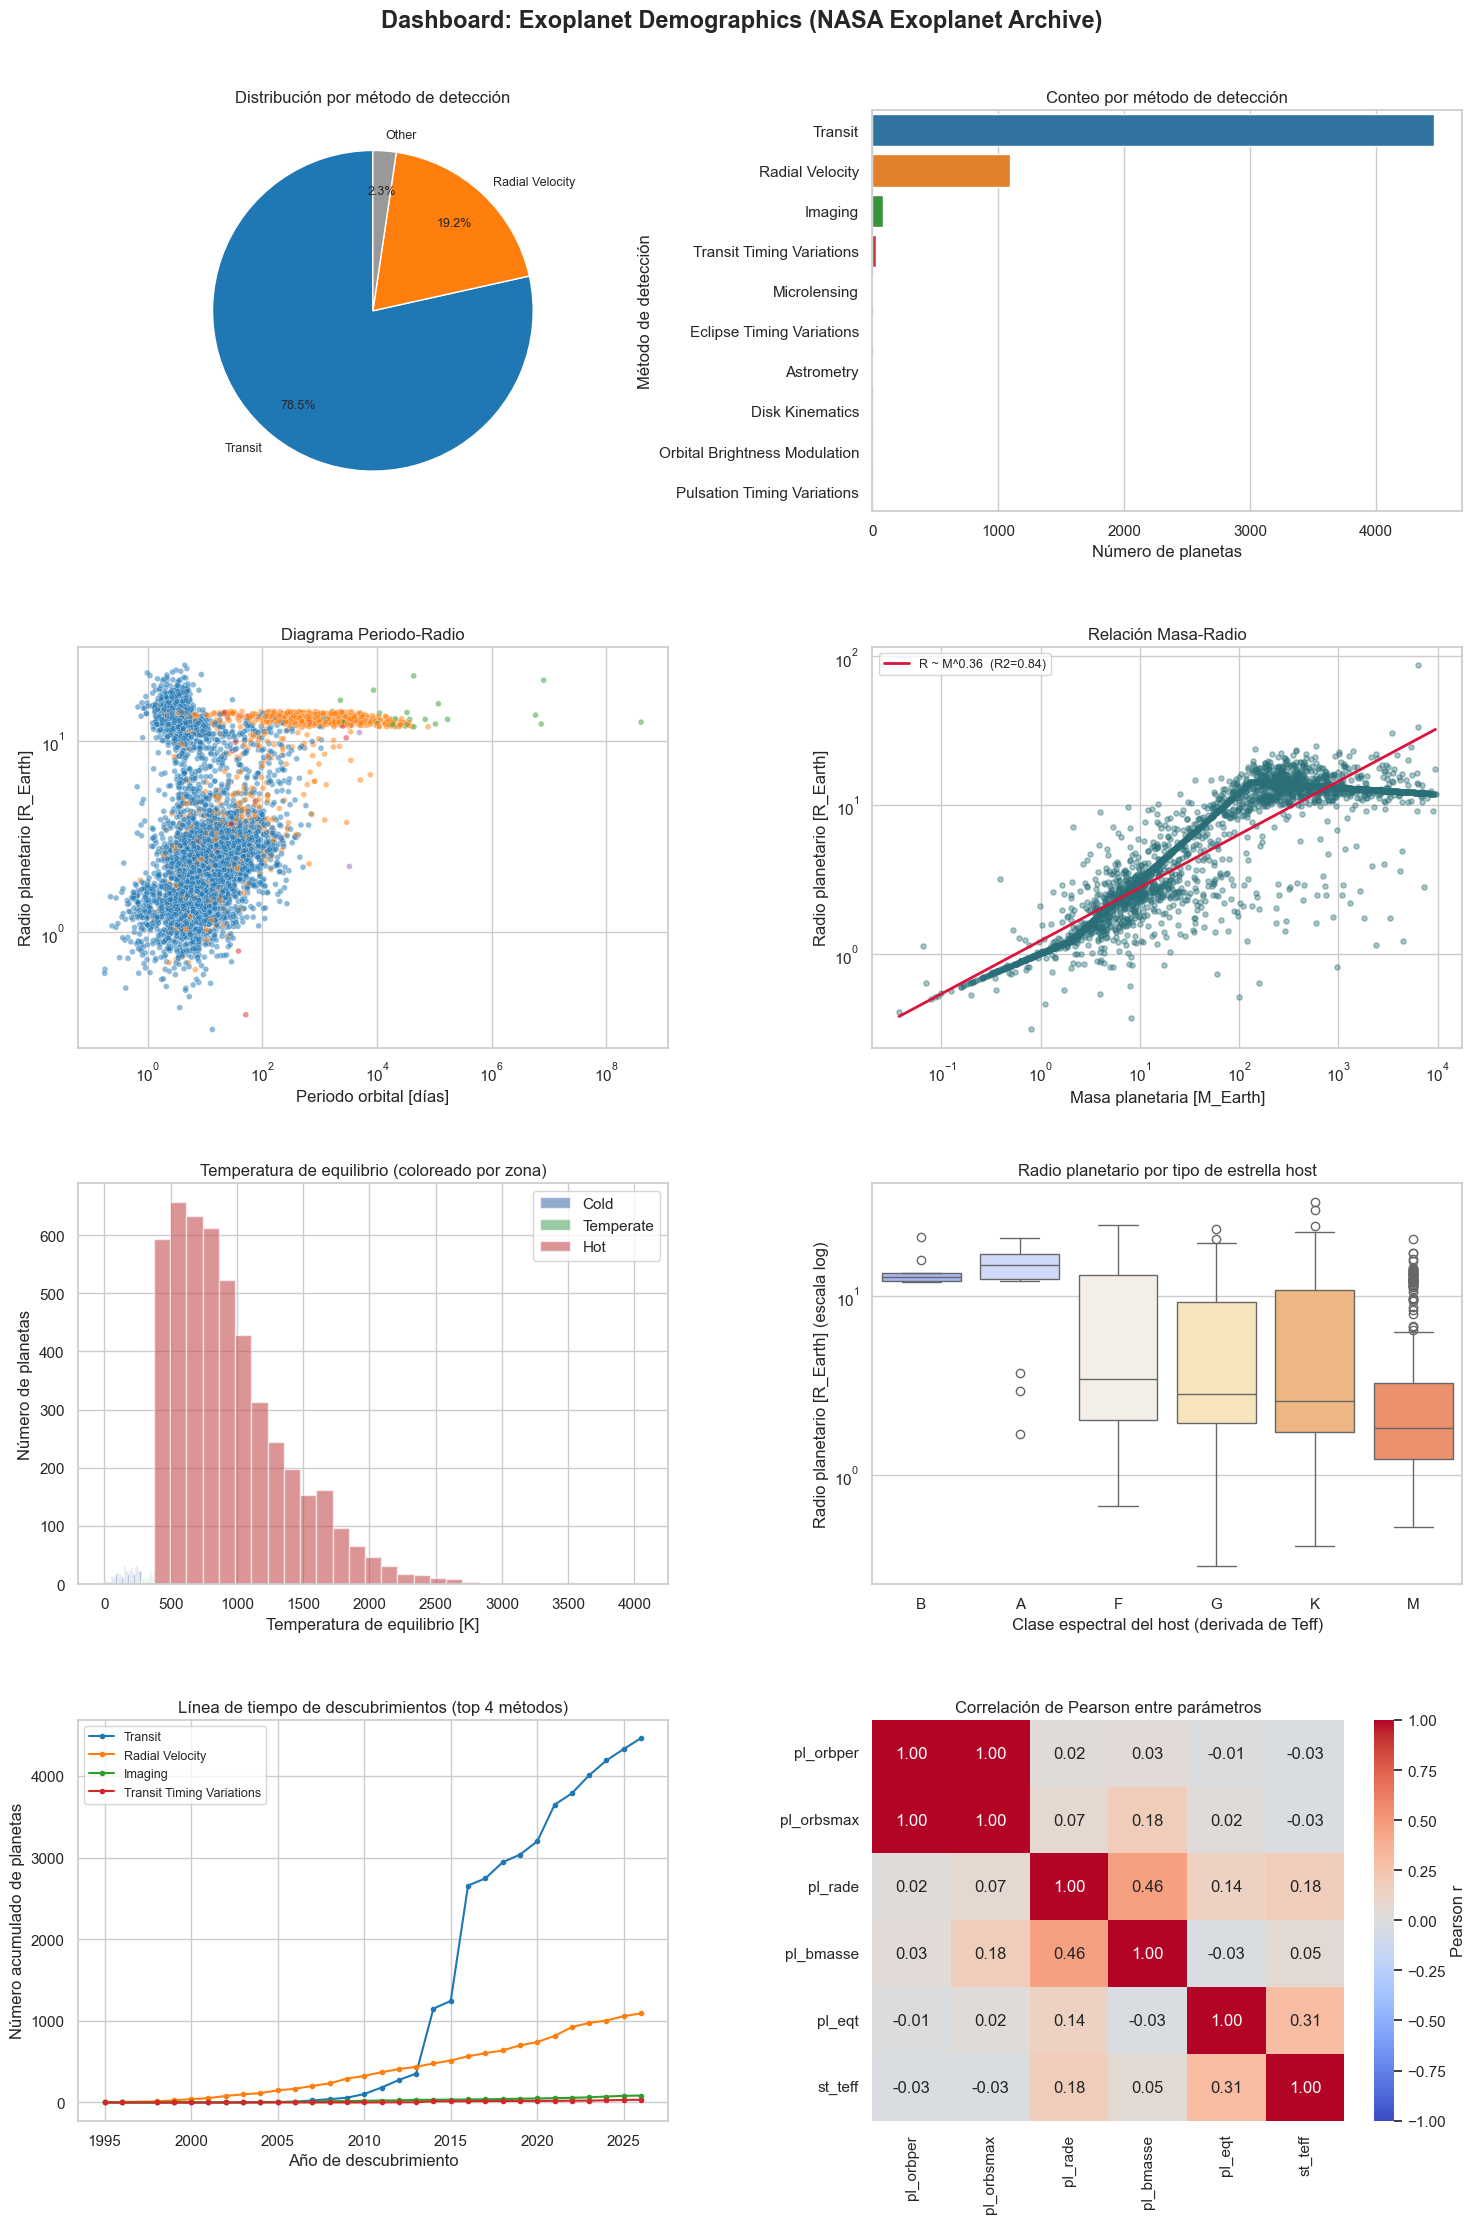

In [51]:
fig, axes = plt.subplots(4, 2, figsize=(15, 22))
fig.suptitle('Dashboard: Exoplanet Demographics (NASA Exoplanet Archive)',
             fontsize=17, fontweight='bold', y=1.01)

for (name, draw_fn), ax in zip(PANELS, axes.flat):
    draw_fn(ax)

plt.tight_layout(h_pad=3.5, w_pad=2.5)
plt.savefig('dashboard.pdf', dpi=150, bbox_inches='tight')
plt.savefig('dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


**Gráficos individuales.** Además del dashboard combinado, exportamos cada panel por
separado (más grande, sin compartir espacio con otros) a `figures/`. Estos son los que se usan
en el reporte escrito, donde cada gráfico necesita su propio pie de figura.


In [14]:
for name, draw_fn in PANELS:
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    draw_fn(ax)
    plt.tight_layout()
    plt.savefig(f'figures/{name}.png', dpi=200, bbox_inches='tight')
    plt.close(fig)

print(f'{len(PANELS)} gráficos individuales guardados en figures/')


8 gráficos individuales guardados en figures/


## Etapa 5 — Interpretación científica

**Panel 1-2 (método de detección):** el método de tránsito domina la muestra (principalmente por la
misión *Kepler/K2* y *TESS*), seguido de velocidad radial. Esto refleja un sesgo observacional: el
tránsito favorece planetas con órbitas alineadas con la línea de visión y periodos cortos, mientras que
velocidad radial favorece planetas masivos cercanos a su estrella. *Limitación:* la muestra no es
representativa de la población real de exoplanetas, solo de lo que somos capaces de detectar con las
técnicas actuales.

**Panel 3 (periodo-radio):** se observa una concentración fuerte de planetas de periodo corto (< 100 días)
detectados por tránsito, consistente con el sesgo de selección mencionado arriba. Los planetas de
velocidad radial aparecen más dispersos en periodo pero tienden a radios/masas mayores (razonable, ya que
RV es más sensible a masa que a radio).

**Panel 4 (masa-radio):** el ajuste sobre toda la muestra da R ∝ M^0.36 (R²=0.84). Ese exponente queda
*entre* los dos regímenes reportados por Chen & Kipping (2017): ~0.28 para planetas terrestres
(R < 1.23 R⊕, donde el radio crece lento porque la roca es casi incompresible) y ~0.59 para
subneptunos/neptunos (1.23-14.3 R⊕, con envolventes de H/He que se inflan más con la masa). Nuestro
ajuste de una sola ley de potencia sobre *toda* la población mezcla ambos regímenes, así que el
0.36 no describe bien a ninguno de los dos por separado — es un promedio entre un régimen rocoso más
plano y uno gaseoso más empinado. Esto se confirma visualmente en el panel: la nube de puntos no sigue
una sola línea recta en log-log, sino que se curva (más empinada por debajo de ~10 M⊕, aplanada por
encima de ~100 M⊕, donde empieza la saturación por degeneración electrónica en gigantes gaseosos).

**Panel 5 (temperatura por zona):** la mayoría de los planetas caen en la zona "Hot" (Teq > 373 K),
de nuevo por el sesgo hacia periodos cortos del método de tránsito — los planetas más cercanos a su
estrella son más fáciles de detectar y tienen temperaturas de equilibrio más altas.

**Panel 6 (radio por clase espectral):** estrellas más frías (K, M) tienden a mostrar planetas detectados
de radios relativamente menores en términos de mediana — consistente con que estrellas M son objetivos
preferidos para encontrar planetas pequeños (menor relación de radio planeta/estrella necesaria para tránsitos
detectables) y con programas específicos de búsqueda de "Tierras" alrededor de enanas M (p.ej. TRAPPIST).

**Panel 7 (timeline):** el salto masivo alrededor de 2014-2016 corresponde al procesamiento estadístico
final del catálogo *Kepler* ("Kepler DR25"), que validó miles de candidatos de una sola vez.

**Panel 8 (correlación):** `pl_orbper` y `pl_orbsmax` correlacionan casi perfectamente (r=1.00), tal como
predice la tercera ley de Kepler (a³ ∝ P² a masa estelar fija) — es la verificación de consistencia interna
más fuerte de todo el dataset. `pl_rade` y `pl_bmasse` correlacionan de forma moderada (r=0.46): positiva
como se espera físicamente, pero lejos de 1 porque, como se vio en el panel 4, la relación no es una sola
ley de potencia limpia sino la mezcla de regímenes rocoso/gaseoso. `pl_eqt` y `st_teff` correlacionan débil
pero positivamente (r=0.31): tiene sentido que estrellas más calientes tiendan a producir temperaturas de
equilibrio más altas en sus planetas, pero la correlación es baja porque `pl_eqt` depende también, y con
más peso, de la distancia orbital (que no está fija entre estrellas). El resto de pares (`pl_orbper` con
`pl_rade`/`pl_bmasse`, `pl_bmasse` con `pl_eqt`) muestran r cercano a 0: no hay razón física para esperar
que el periodo orbital o la temperatura determinen por sí solos el tamaño o la masa de un planeta.

### Hallazgos principales (resumen)
1. El método de tránsito domina la muestra (78.5%) por sesgo de selección geométrico y temporal ligado a
   Kepler/K2 y TESS, no por ser el mecanismo físicamente más común de formación planetaria.
2. El ajuste masa-radio (R ~ M^0.36) queda entre los exponentes reportados por Chen & Kipping (2017) para
   planetas terrestres (~0.28) y subneptunos (~0.59), porque mezcla ambos regímenes físicos en un solo ajuste.
3. La mayoría de los planetas confirmados están en la zona "caliente" — reflejo del sesgo hacia periodos
   orbitales cortos, no una propiedad intrínseca de la población galáctica de exoplanetas.
4. `pl_orbper` y `pl_orbsmax` correlacionan casi perfectamente (r=1.00), consistente con la tercera ley de
   Kepler y usado aquí como chequeo de consistencia interna de los datos.
5. La clase espectral derivada de Teff (en vez del campo `st_spectype`, vacío en ~62% de los casos) permitió
   clasificar más del 99% de las estrellas de la muestra.

### Referencias
- NASA Exoplanet Archive, https://exoplanetarchive.ipac.caltech.edu/
- Chen, J. & Kipping, D. (2017), *Probabilistic Forecasting of the Masses and Radii of Other Worlds*, ApJ 834, 17.
